**Introducción a la Ciencia de Datos 2026**
Posgrado en Ciencias de la Computación - CICESE
Dr. Irvin Hussein López Nava

## ICD - 11: Regresión logística

Sesión 11 del curso. Diapositivas: [icd-11-regresion-logistica.pdf](https://github.com/husseinlopez/icd2026/blob/main/clases/icd-11-regresion-logistica.pdf)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/husseinlopez/icd2026/blob/main/icd-11-regresion-logistica.ipynb)

La sesión 10 terminó con una pregunta: ¿qué pasa si la variable objetivo es una clase? Una recta ajustada a ceros y unos predice números que no son probabilidades, y su porcentaje de aciertos apenas le gana a no hacer nada. En clase vimos el remedio para lo primero: la regresión logística, que modela la probabilidad con una curva que se queda entre 0 y 1, se ajusta por máxima verosimilitud y tiene coeficientes que se leen como razones de momios. También vimos que, para clasificar, hace falta un umbral, y que la matriz de confusión desglosa los aciertos y los errores por clase.

Este notebook retoma el ejemplo donde lo dejó el notebook 10: la progresión alta de la diabetes, con el IMC y la misma partición. En la primera parte cambiamos la recta por la curva, la ajustamos a mano con descenso de gradiente y leemos sus coeficientes. En la segunda evaluamos sus decisiones con la matriz de confusión y movemos el umbral. Cierra con el vino de la Tarea 3.

---

### Preparación

Las mismas bibliotecas de la sesión 10: NumPy, pandas, Matplotlib, scikit-learn para predecir y statsmodels para explicar. Vienen instaladas en Colab; en tu máquina, `pip install -r requirements.txt` desde la carpeta del repositorio.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import statsmodels

print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)
print("matplotlib  ", __import__("matplotlib").__version__)
print("scikit-learn", sklearn.__version__)
print("statsmodels ", statsmodels.__version__)

numpy        2.1.3
pandas       2.2.3
matplotlib   3.10.0
scikit-learn 1.6.1
statsmodels  0.15.0


Paleta y estilo de las sesiones anteriores. El naranja sigue siendo lo que produce el modelo; la curva logística va en el azul de los títulos de las diapositivas, para distinguirla de la recta.

In [21]:
AZUL_OSCURO = "#112057"
AZUL = "#7697CD"
AZUL_MEDIO = "#3C51A9"   # la curva logística
NARANJA = "#E76A28"      # lo que produce el modelo
GRIS = "#5B6584"

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlecolor": AZUL_OSCURO,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.labelcolor": AZUL_OSCURO,
    "axes.edgecolor": "#C9CFDF",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#E3E6EF",
    "xtick.color": GRIS,
    "ytick.color": GRIS,
    "legend.frameon": False,
})

SEMILLA = 42    # fija las particiones para que los resultados se repitan

---

### Los datos

Los mismos 442 pacientes de la sesión 10 (Efron *et al.*, 2004), con las variables en sus unidades originales. Allí está su descripción completa. Como en la sección 6 del notebook 10, la clase es la **progresión alta**: un valor de 200 o más un año después. El corte es nuestro, no clínico.

Partimos la tabla completa con la misma semilla que la sesión 10. Así quedan en prueba los mismos 89 pacientes, tanto si usamos solo el IMC como si usamos las diez variables.

In [22]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

diabetes = load_diabetes(as_frame=True, scaled=False)
X = diabetes.data
alta = (diabetes.target >= 200).astype(int)      # 1: progresión alta; 0: no
tabla = X.assign(alta=alta)

entrena, prueba = train_test_split(tabla, test_size=0.2, random_state=SEMILLA)

print(f"Progresión alta: {alta.sum()} de {len(alta)} pacientes ({alta.mean():.0%})")
print(f"Entrenamiento: {len(entrena)} pacientes, {entrena['alta'].sum()} con progresión alta")
print(f"Prueba:         {len(prueba)} pacientes, {prueba['alta'].sum()} con progresión alta")

Progresión alta: 127 de 442 pacientes (29%)
Entrenamiento: 353 pacientes, 103 con progresión alta
Prueba:         89 pacientes, 24 con progresión alta


Los cuatro números con los que terminó el notebook 10, para la recta ajustada con el IMC:

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

recta = LinearRegression().fit(entrena[["bmi"]], entrena["alta"])
y_gorro = recta.predict(prueba[["bmi"]])            # números, no clases
clase_recta = (y_gorro >= 0.5).astype(int)
siempre_no = np.zeros(len(prueba), dtype=int)

print(f"Aciertos de la recta:            {accuracy_score(prueba['alta'], clase_recta):.1%}")
print(f"Aciertos diciendo siempre «no»:  {accuracy_score(prueba['alta'], siempre_no):.1%}")
print(f"ŷ fuera de [0, 1]:               {((y_gorro < 0) | (y_gorro > 1)).sum()} de {len(y_gorro)}")
print(f"Progresiones altas detectadas:   {((clase_recta == 1) & (prueba['alta'] == 1)).sum()} de {prueba['alta'].sum()}")

Aciertos de la recta:            74.2%
Aciertos diciendo siempre «no»:  73.0%
ŷ fuera de [0, 1]:               16 de 89
Progresiones altas detectadas:   8 de 24


**Lectura.** Son los mismos de la sesión 10, y apuntan a dos problemas distintos (lámina 9). El primero es del **modelo**: 16 predicciones no se pueden leer como probabilidades. El segundo es de la **decisión**: 74 % de aciertos contra 73 % de no hacer nada, y solo 8 de 24 casos detectados. Las secciones 1 a 3 atienden el primero; las 4 a 6, el segundo.

---

## 1. De la recta a la curva

La regresión logística modela la probabilidad de la clase 1 con la función logística (lámina 25):

$$p = \frac{1}{1 + e^{-(\theta_0 + \theta_1 x)}}$$

En scikit-learn es `LogisticRegression`. Un detalle antes de usarla: por omisión agrega una penalización a los coeficientes, la regularización, que no forma parte de este curso. Con `C=np.inf` se desactiva, y el ajuste es el de máxima verosimilitud de la lámina 26, el mismo que da statsmodels. En la sección 2 comparamos las dos versiones.

In [24]:
from sklearn.linear_model import LogisticRegression

curva = LogisticRegression(C=np.inf).fit(entrena[["bmi"]], entrena["alta"])
theta0, theta1 = curva.intercept_[0], curva.coef_[0, 0]

print(f"θ0 = {theta0:.3f}")
print(f"θ1 = {theta1:.4f}")

θ0 = -9.624
θ1 = 0.3188


Las dos, con los pacientes de entrenamiento:

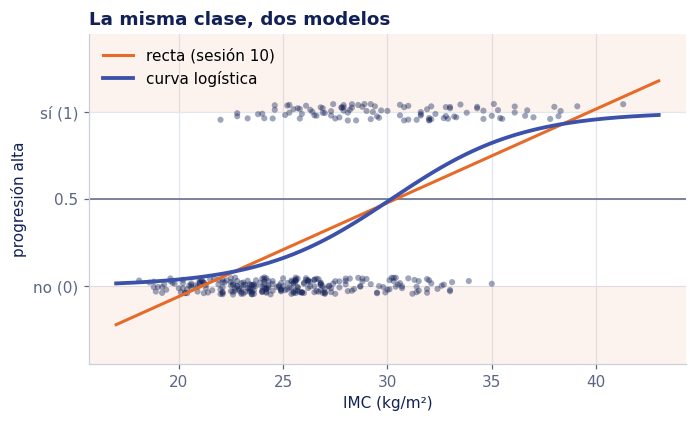

In [25]:
def logistica(z):
    return 1 / (1 + np.exp(-z))


rng = np.random.default_rng(SEMILLA)
fig, ax = plt.subplots(figsize=(7, 3.9))

ax.axhspan(-0.45, 0, color=NARANJA, alpha=0.08, linewidth=0)
ax.axhspan(1, 1.45, color=NARANJA, alpha=0.08, linewidth=0)
ax.axhline(0.5, color=GRIS, linewidth=1)
ax.scatter(entrena["bmi"], entrena["alta"] + rng.uniform(-0.05, 0.05, len(entrena)), s=16,
           color=AZUL_OSCURO, alpha=0.4, edgecolor="none")
malla = np.linspace(17, 43, 200)
ax.plot(malla, recta.intercept_ + recta.coef_[0] * malla, color=NARANJA, linewidth=2, label="recta (sesión 10)")
ax.plot(malla, logistica(theta0 + theta1 * malla), color=AZUL_MEDIO, linewidth=2.5, label="curva logística")

ax.set_yticks([0, 0.5, 1], ["no (0)", "0.5", "sí (1)"])
ax.set_ylim(-0.45, 1.45)
ax.set_xlabel("IMC (kg/m²)")
ax.set_ylabel("progresión alta")
ax.set_title("La misma clase, dos modelos")
ax.legend(loc="upper left")
plt.show()

**Lectura.** La curva nunca sale de [0, 1]: en un IMC bajo se acerca a 0 sin cruzarlo, y en uno alto se acerca a 1. La recta, en cambio, predice valores negativos por debajo de un IMC de 21. Pero las dos cruzan 0.5 casi en el mismo lugar. ¿Cuánto cambian entonces las decisiones?

In [26]:
p_prueba = curva.predict_proba(prueba[["bmi"]])[:, 1]     # probabilidad de la clase 1
clase_curva = (p_prueba >= 0.5).astype(int)

cruce_recta = (0.5 - recta.intercept_) / recta.coef_[0]
cruce_curva = -theta0 / theta1            # p = 0.5 cuando θ0 + θ1·x = 0
distintas = clase_curva != clase_recta

print(f"La recta cruza 0.5 en un IMC de {cruce_recta:.2f}; la curva, en {cruce_curva:.2f}")
print(f"Decisiones distintas: {distintas.sum()} de {len(prueba)}  (IMC {prueba.loc[distintas, 'bmi'].tolist()})")
print()
print(f"Aciertos de la curva:            {accuracy_score(prueba['alta'], clase_curva):.1%}")
print(f"ŷ fuera de [0, 1]:               {((p_prueba < 0) | (p_prueba > 1)).sum()} de {len(p_prueba)}")
print(f"Progresiones altas detectadas:   {((clase_curva == 1) & (prueba['alta'] == 1)).sum()} de {prueba['alta'].sum()}")

La recta cruza 0.5 en un IMC de 30.40; la curva, en 30.19
Decisiones distintas: 1 de 89  (IMC [30.2])

Aciertos de la curva:            73.0%
ŷ fuera de [0, 1]:               0 de 89
Progresiones altas detectadas:   8 de 24


**Lectura.** Con una sola variable, las dos reglas son «IMC mayor que un corte», y los cortes casi coinciden: 30.4 y 30.2. Solo cambia la decisión de un paciente, el que tiene un IMC de 30.2, que la curva clasifica como progresión alta. Por eso la logística acierta 73.0 % en lugar de 74.2 % y detecta los mismos 8 de 24. Arregla la probabilidad, no la decisión (lámina 35). Para cambiar las decisiones hay que cambiar las variables o el umbral, y lo veremos en las secciones 4 y 5.

---

## 2. Cómo se ajusta

La recta tenía solución cerrada; la curva no. Sus parámetros se eligen minimizando la log-loss, el promedio de $-\ln$ de la probabilidad que el modelo le asignó a la clase observada (lámina 26):

$$J(\theta) = -\frac{1}{n}\sum_{i=1}^{n}\left[\,y_i \ln p_i + (1 - y_i)\ln(1 - p_i)\,\right]$$

Las derivadas tienen la misma forma que en la sesión 10, con $p_i$ en lugar de $\hat{y}_i$ (lámina 27):

$$\theta_0 \leftarrow \theta_0 - \alpha\,\frac{1}{n}\sum_{i=1}^{n}(p_i - y_i) \qquad\qquad \theta_1 \leftarrow \theta_1 - \alpha\,\frac{1}{n}\sum_{i=1}^{n}(p_i - y_i)\,x_i$$

La función es la de la sesión 10 con dos líneas distintas: la predicción pasa por la logística y el costo es la log-loss.

In [27]:
def descenso_gradiente_logistico(x, y, alfa, iteraciones):
    # Regresión logística simple por descenso de gradiente (láminas 26 y 27).
    n = len(x)
    theta0, theta1 = 0.0, 0.0
    historia = []
    for _ in range(iteraciones):
        p = logistica(theta0 + theta1 * x)                      # en lugar de ŷ = θ0 + θ1·x
        costo = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
        historia.append(costo)
        d_theta0 = np.sum(p - y) / n                            # ∂J/∂θ0
        d_theta1 = np.sum((p - y) * x) / n                      # ∂J/∂θ1
        theta0 = theta0 - alfa * d_theta0
        theta1 = theta1 - alfa * d_theta1
    return theta0, theta1, np.array(historia)

Como en la sesión 10, estandarizamos el IMC antes de iterar. En kg/m², el mismo problema necesitaría una α diminuta y cientos de miles de pasos. Al final traducimos los parámetros a kg/m² con las mismas fórmulas: $\theta_1 = b / s_x$ y $\theta_0 = a - \theta_1\,\bar{x}$.

In [28]:
import statsmodels.formula.api as smf

x = entrena["bmi"].to_numpy()
y_obs = entrena["alta"].to_numpy()
media_x, desv_x = x.mean(), x.std()

a, b, historia = descenso_gradiente_logistico((x - media_x) / desv_x, y_obs, alfa=1.0, iteraciones=200)
gd_theta1 = b / desv_x
gd_theta0 = a - gd_theta1 * media_x

sm_cruda = smf.logit("alta ~ bmi", data=entrena).fit(disp=0)
por_omision = LogisticRegression().fit(entrena[["bmi"]], entrena["alta"])   # C=1: regularizada

pd.DataFrame({
    "descenso de gradiente (z, 200 pasos)": [gd_theta0, gd_theta1],
    "scikit-learn, C=np.inf": [theta0, theta1],
    "statsmodels": [sm_cruda.params["Intercept"], sm_cruda.params["bmi"]],
    "scikit-learn por omisión (C=1)": [por_omision.intercept_[0], por_omision.coef_[0, 0]],
}, index=["θ0", "θ1"]).round(4)

,"descenso de gradiente (z, 200 pasos)","scikit-learn, C=np.inf",statsmodels,scikit-learn por omisión (C=1)
θ0,-9.6236,-9.6237,-9.6236,-9.6107
θ1,0.3188,0.3188,0.3188,0.3183


**Lectura.** Tres caminos llegan a la misma curva: el descenso de gradiente, scikit-learn sin regularizar y statsmodels coinciden, salvo una diezmilésima en θ0 que viene de la tolerancia con que se detiene cada método. La versión por omisión de scikit-learn queda apenas por debajo (0.3183 contra 0.3188). Con una variable y 353 pacientes la penalización casi no se nota, pero con muchas variables sí; por eso conviene saber que está ahí.

¿Qué tan rápido llega? La log-loss en cada paso:

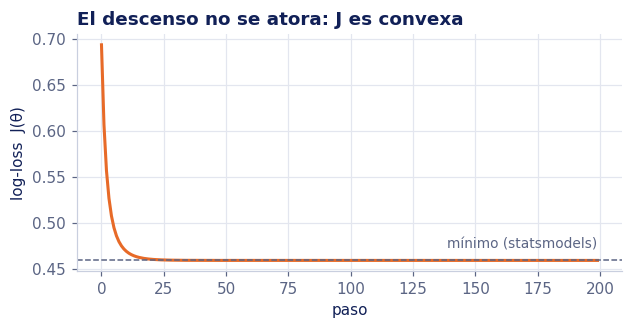

In [29]:
fig, ax = plt.subplots(figsize=(6.4, 2.8))
ax.plot(historia, color=NARANJA, linewidth=2)
ax.axhline(-sm_cruda.llf / len(entrena), color=GRIS, linewidth=1, linestyle="--")
ax.text(len(historia) - 1, -sm_cruda.llf / len(entrena) + 0.01, "mínimo (statsmodels)", color=GRIS,
        ha="right", va="bottom", fontsize=9)
ax.set_xlabel("paso")
ax.set_ylabel("log-loss  J(θ)")
ax.set_title("El descenso no se atora: J es convexa")
plt.show()

**Lectura.** Empieza en 0.693, que es $\ln 2$: con θ = 0, la curva predice 0.5 para todos y cada observación cuesta $-\ln 0.5$. En unos 20 pasos queda prácticamente en el mínimo. Como $J$ es convexa, no hay mínimos locales en los que atorarse, y por eso scikit-learn y statsmodels pueden usar métodos más rápidos que llegan al mismo punto.

---

## 3. Cómo se lee un coeficiente

En la regresión lineal, $\theta_1$ decía cuántas unidades cambia la predicción. Aquí dice cuánto cambia el **logaritmo de los momios**, y al exponenciarlo se obtiene la razón de momios (lámina 28):

$$\frac{\text{momios}(x + 1)}{\text{momios}(x)} = e^{\theta_1}$$

statsmodels da la incertidumbre que scikit-learn no reporta, igual que en la sesión 10. Su interfaz de fórmulas es la misma: `"alta ~ bmi"` es la cruda y, al sumar variables a la derecha, se ajusta por ellas. Calculamos la razón de momios y su intervalo exponenciando el coeficiente y los extremos de su intervalo.

In [30]:
sm_ajustada = smf.logit("alta ~ bmi + age + sex + bp + s1 + s2 + s3 + s4 + s5 + s6", data=entrena).fit(disp=0)

filas = {}
for nombre, modelo in [("cruda: solo IMC", sm_cruda), ("ajustada: 10 variables", sm_ajustada)]:
    inferior, superior = np.exp(modelo.conf_int().loc["bmi"])
    filas[nombre] = {"θ bmi": f"{modelo.params['bmi']:.3f}",
                     "razón de momios": f"{np.exp(modelo.params['bmi']):.3f}",
                     "IC 95 %": f"{inferior:.3f} a {superior:.3f}",
                     "p": f"{modelo.pvalues['bmi']:.1e}"}
pd.DataFrame(filas).T

,θ bmi,razón de momios,IC 95 %,p
cruda: solo IMC,0.319,1.375,1.276 a 1.483,7.5e-17
ajustada: 10 variables,0.206,1.228,1.125 a 1.342,4.9e-06


**Lectura.** Sin ajustar, cada kg/m² de IMC multiplica por 1.375 los momios de progresión alta, con un intervalo de 1.28 a 1.48. Ajustando por las otras nueve variables baja a 1.23, de 1.12 a 1.34. Es el mismo patrón de la regresión lineal en la sesión 10: parte de la asociación cruda venía de lo que el IMC comparte con la presión y los triglicéridos. En un artículo se reportaría así: «por cada kg/m² de IMC, los momios de progresión alta aumentaron 23 % (RM 1.23; IC 95 %: 1.12 a 1.34), ajustando por edad, sexo, presión arterial y mediciones séricas».

La razón de momios multiplica los momios, no la probabilidad. Lo que cambia la probabilidad depende de en qué parte de la curva esté el paciente:

In [31]:
filas = []
for imc in [20, 30]:
    p0, p1 = logistica(theta0 + theta1 * imc), logistica(theta0 + theta1 * (imc + 1))
    filas.append({"de IMC": imc, "a IMC": imc + 1, "p antes": p0, "p después": p1,
                  "cambio en p": p1 - p0, "razón de momios": (p1 / (1 - p1)) / (p0 / (1 - p0))})
pd.DataFrame(filas).round(3)

,de IMC,a IMC,p antes,p después,cambio en p,razón de momios
0,20,21,0.037,0.051,0.013,1.375
1,30,31,0.485,0.564,0.079,1.375


**Lectura.** De 20 a 21 kg/m², la probabilidad sube 1.3 puntos porcentuales; de 30 a 31, sube 7.9. En los dos casos los momios se multiplican por 1.375. Cerca de 0.5 la curva tiene su pendiente máxima, y en los extremos se aplana.

---

## 4. La matriz de confusión

De aquí en adelante nos ocupamos del segundo problema, la decisión. El porcentaje de aciertos junta los dos tipos de error en un solo número. La matriz de confusión los separa (láminas 36 a 39): filas para la clase real, columnas para la predicha. Primero la armamos a mano, contando, con la curva y el umbral de 0.5.

In [32]:
real = prueba["alta"].to_numpy()

vp = int(((clase_curva == 1) & (real == 1)).sum())    # verdaderos positivos
fn = int(((clase_curva == 0) & (real == 1)).sum())    # falsos negativos
fp = int(((clase_curva == 1) & (real == 0)).sum())    # falsos positivos
vn = int(((clase_curva == 0) & (real == 0)).sum())    # verdaderos negativos

pd.DataFrame([[vp, fn], [fp, vn]],
             index=["real: alta", "real: no alta"],
             columns=["predicha: alta", "predicha: no alta"])

,predicha: alta,predicha: no alta
real: alta,8,16
real: no alta,8,57


scikit-learn la calcula con `confusion_matrix`. Ordena las clases de menor a mayor, así que la primera fila y la primera columna son la clase 0. Es la misma información en otro orden: conviene revisar siempre qué va en cada eje, porque cada texto lo pone distinto (en el meme de la lámina 37, las predicciones van en las filas).

[[57  8]
 [16  8]]


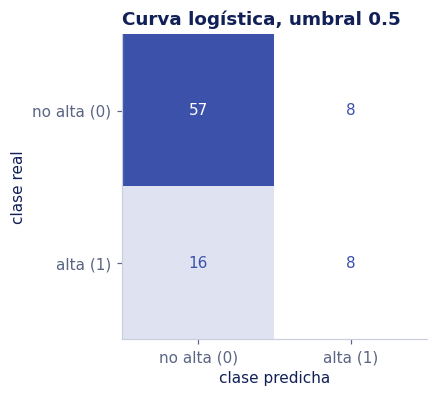

In [33]:
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

azules = LinearSegmentedColormap.from_list("azules", ["#FFFFFF", AZUL_MEDIO])
matriz = confusion_matrix(real, clase_curva)
print(matriz)

fig, ax = plt.subplots(figsize=(4.2, 3.6))
ConfusionMatrixDisplay(matriz, display_labels=["no alta (0)", "alta (1)"]).plot(
    ax=ax, cmap=azules, colorbar=False)
ax.grid(False)
ax.set_xlabel("clase predicha")
ax.set_ylabel("clase real")
ax.set_title("Curva logística, umbral 0.5")
plt.show()

De las cuatro celdas salen las métricas de la lámina 40. Las calculamos con sus fórmulas y comprobamos con scikit-learn, que no tiene una función para la especificidad: es la sensibilidad de la clase 0.

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

exactitud = (vp + vn) / (vp + vn + fp + fn)
sensibilidad = vp / (vp + fn)
especificidad = vn / (vn + fp)
precision = vp / (vp + fp)
f1 = 2 * precision * sensibilidad / (precision + sensibilidad)

pd.DataFrame({
    "a mano": [exactitud, sensibilidad, especificidad, precision, f1],
    "scikit-learn": [accuracy_score(real, clase_curva), recall_score(real, clase_curva),
                     recall_score(real, clase_curva, pos_label=0), precision_score(real, clase_curva),
                     f1_score(real, clase_curva)],
}, index=["exactitud", "sensibilidad", "especificidad", "precisión", "F1"]).round(3)

,a mano,scikit-learn
exactitud,0.730,0.730
sensibilidad,0.333,0.333
especificidad,0.877,0.877
precisión,0.500,0.500
F1,0.400,0.400


**Lectura.** La exactitud de 0.73 esconde dos comportamientos muy distintos. Con los pacientes sin progresión alta el modelo va bien: la especificidad es 0.88. Con los que sí la tienen, falla dos de cada tres: la sensibilidad es 0.33. De los 16 que marca como progresión alta, la mitad lo son (precisión 0.50). El F1 resume precisión y sensibilidad en 0.40.

La matriz de confusión de la recta casi no cambia, por la razón de la sección 1. Lo que sí cambia la matriz es usar más información. Con las diez variables, estandarizadas dentro de un `Pipeline` como en la sesión 9:

In [35]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

variables = list(X.columns)
curva_10 = make_pipeline(StandardScaler(), LogisticRegression(C=np.inf)).fit(entrena[variables], entrena["alta"])
clase_10 = curva_10.predict(prueba[variables])          # predict usa el umbral de 0.5

for nombre, pred in [("recta, IMC", clase_recta), ("curva, IMC", clase_curva), ("curva, 10 variables", clase_10)]:
    vn_, fp_, fn_, vp_ = confusion_matrix(real, pred).ravel()
    print(f"{nombre:<20}  exactitud {accuracy_score(real, pred):.3f}   "
          f"sensibilidad {vp_ / (vp_ + fn_):.3f}   especificidad {vn_ / (vn_ + fp_):.3f}   [VP {vp_}, FN {fn_}, FP {fp_}, VN {vn_}]")

recta, IMC            exactitud 0.742   sensibilidad 0.333   especificidad 0.892   [VP 8, FN 16, FP 7, VN 58]
curva, IMC            exactitud 0.730   sensibilidad 0.333   especificidad 0.877   [VP 8, FN 16, FP 8, VN 57]
curva, 10 variables   exactitud 0.820   sensibilidad 0.583   especificidad 0.908   [VP 14, FN 10, FP 6, VN 59]


**Lectura.** La recta y la curva con el IMC tienen la misma sensibilidad; difieren en un falso positivo. Con las diez variables, la curva detecta 14 de 24 en lugar de 8, con menos falsas alarmas. La exactitud sube de 0.73 a 0.82, pero lo informativo es por qué: la sensibilidad pasó de 0.33 a 0.58.

---

## 5. El umbral es una decisión

`predict` usa 0.5, pero el umbral no es parte del modelo (lámina 25). Con las mismas probabilidades, otro umbral produce otras decisiones. Probamos cuatro con la curva del IMC; para cada uno, el corte equivalente de IMC sale de despejar $x$ en $\theta_0 + \theta_1 x = \ln\frac{t}{1-t}$.

In [36]:
filas = []
for t in [0.5, 0.4, 0.3, 0.2]:
    pred = (p_prueba >= t).astype(int)
    vn_, fp_, fn_, vp_ = confusion_matrix(real, pred).ravel()
    filas.append({"umbral": t,
                  "IMC ≥": (np.log(t / (1 - t)) - theta0) / theta1,
                  "detectados": f"{vp_} de {vp_ + fn_}",
                  "falsas alarmas": fp_,
                  "sensibilidad": vp_ / (vp_ + fn_),
                  "especificidad": vn_ / (vn_ + fp_),
                  "precisión": vp_ / (vp_ + fp_)})
pd.DataFrame(filas).round(2)

,umbral,IMC ≥,detectados,falsas alarmas,sensibilidad,especificidad,precisión
0,0.5,30.19,8 de 24,8,0.33,0.88,0.50
1,0.4,28.92,11 de 24,13,0.46,0.80,0.46
2,0.3,27.53,15 de 24,17,0.62,0.74,0.47
3,0.2,25.84,17 de 24,19,0.71,0.71,0.47


**Lectura.** Bajar el umbral de 0.5 a 0.3 equivale a bajar el corte de IMC de 30.2 a 27.5. Se detectan 15 casos en lugar de 8, a cambio de 17 falsas alarmas en lugar de 8. La sensibilidad sube de 0.33 a 0.62 y la especificidad baja de 0.88 a 0.74. Nada del modelo cambió.

El intercambio completo, con todos los umbrales:

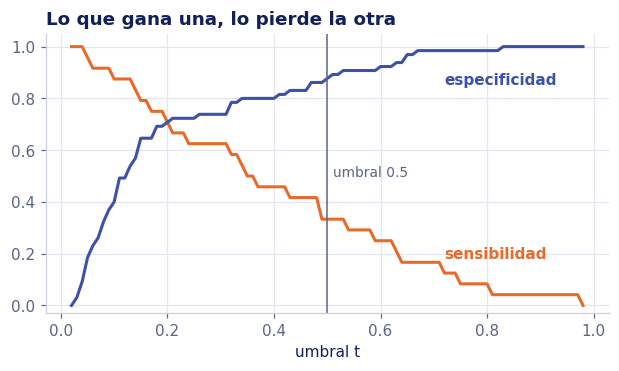

In [37]:
umbrales = np.linspace(0.02, 0.98, 97)
sens, espec = [], []
for t in umbrales:
    pred = (p_prueba >= t).astype(int)
    vn_, fp_, fn_, vp_ = confusion_matrix(real, pred, labels=[0, 1]).ravel()
    sens.append(vp_ / (vp_ + fn_))
    espec.append(vn_ / (vn_ + fp_))

fig, ax = plt.subplots(figsize=(6.6, 3.3))
ax.plot(umbrales, sens, color=NARANJA, linewidth=2)
ax.plot(umbrales, espec, color=AZUL_MEDIO, linewidth=2)
ax.axvline(0.5, color=GRIS, linewidth=1)
ax.text(0.72, 0.17, "sensibilidad", color=NARANJA, fontsize=10, fontweight="bold", va="bottom")
ax.text(0.72, 0.9, "especificidad", color=AZUL_MEDIO, fontsize=10, fontweight="bold", va="top")
ax.text(0.51, 0.5, "umbral 0.5", color=GRIS, fontsize=9)
ax.set_xlabel("umbral t")
ax.set_ylim(-0.03, 1.05)
ax.set_title("Lo que gana una, lo pierde la otra")
plt.show()

**Lectura.** Con un umbral muy bajo, el modelo marca a todos como progresión alta: detecta todos los casos y no acierta ningún negativo. Con uno muy alto ocurre lo contrario. Entre los dos extremos, cada umbral es un punto distinto del mismo intercambio. ¿Cuál conviene? Depende de cuánto cuesta cada error: no es lo mismo dejar sin seguimiento a un paciente que va a empeorar que citar a revisión a uno que no. La sesión 12 lleva este intercambio a la curva ROC.

---

## 6. De vuelta al vino

En la Tarea 3 ajustaron una recta a `bueno` (calidad ≥ 7) en el vino tinto, con las once variables y la partición 80/20 de `random_state=42`. El archivo está en `datos/`:

- **En tu máquina.** La primera línea funciona tal cual desde la carpeta del repositorio clonado.
- **En Colab.** Comenta la primera línea y descomenta la segunda.

In [38]:
# vinos = pd.read_csv("datos/winequality-red.csv")
vinos = pd.read_csv("https://raw.githubusercontent.com/husseinlopez/icd2026/main/datos/winequality-red.csv")

X_vino = vinos.drop(columns="quality")
bueno = (vinos["quality"] >= 7).astype(int)
Xv_entrena, Xv_prueba, b_entrena, b_prueba = train_test_split(
    X_vino, bueno, test_size=0.2, random_state=SEMILLA)

recta_vino = LinearRegression().fit(Xv_entrena, b_entrena)
yv = recta_vino.predict(Xv_prueba)
clase_recta_vino = (yv >= 0.5).astype(int)

curva_vino = make_pipeline(StandardScaler(), LogisticRegression(C=np.inf)).fit(Xv_entrena, b_entrena)
pv = curva_vino.predict_proba(Xv_prueba)[:, 1]
clase_curva_vino = (pv >= 0.5).astype(int)

print(f"Vinos de prueba: {len(b_prueba)}, buenos: {b_prueba.sum()}")
print(f"Diciendo siempre «no bueno»: {accuracy_score(b_prueba, np.zeros(len(b_prueba))):.1%}")
print(f"Recta:     {accuracy_score(b_prueba, clase_recta_vino):.1%} de aciertos, {((yv < 0) | (yv > 1)).sum()} ŷ fuera de [0, 1]")
print(f"Logística: {accuracy_score(b_prueba, clase_curva_vino):.1%} de aciertos, {((pv < 0) | (pv > 1)).sum()} fuera de [0, 1]")

Vinos de prueba: 320, buenos: 47
Diciendo siempre «no bueno»: 85.3%
Recta:     86.2% de aciertos, 82 ŷ fuera de [0, 1]
Logística: 86.2% de aciertos, 0 fuera de [0, 1]


Las dos aciertan exactamente lo mismo: 276 de 320. ¿Se equivocan igual?

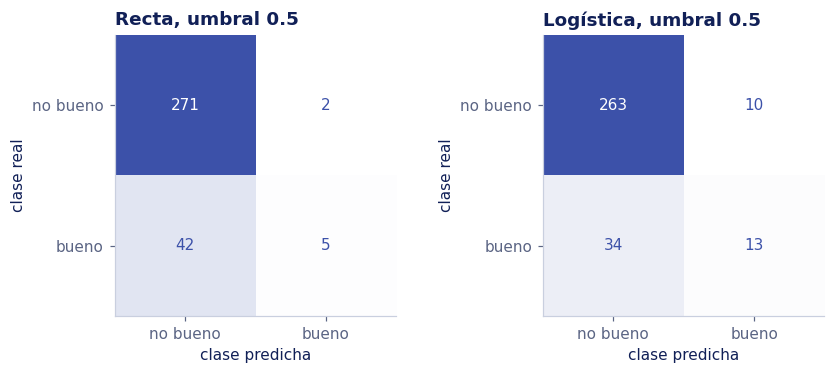

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, pred, nombre in [(axes[0], clase_recta_vino, "Recta"), (axes[1], clase_curva_vino, "Logística")]:
    ConfusionMatrixDisplay(confusion_matrix(b_prueba, pred), display_labels=["no bueno", "bueno"]).plot(
        ax=ax, cmap=azules, colorbar=False)
    ax.grid(False)
    ax.set_xlabel("clase predicha")
    ax.set_ylabel("clase real")
    ax.set_title(f"{nombre}, umbral 0.5")
plt.tight_layout()
plt.show()

**Lectura.** No. La recta detecta 5 de los 47 vinos buenos con 2 falsas alarmas; la logística detecta 13 con 10 falsas alarmas. Mismo porcentaje de aciertos, decisiones distintas. Es lo que la exactitud no puede mostrar (lámina 35).

Y la logística, como cualquier clasificador con probabilidades, deja mover el umbral:

In [40]:
filas = []
for t in [0.5, 0.3, 0.2]:
    pred = (pv >= t).astype(int)
    vn_, fp_, fn_, vp_ = confusion_matrix(b_prueba, pred).ravel()
    filas.append({"umbral": t, "detectados": f"{vp_} de {vp_ + fn_}", "falsas alarmas": fp_,
                  "sensibilidad": vp_ / (vp_ + fn_), "especificidad": vn_ / (vn_ + fp_),
                  "precisión": vp_ / (vp_ + fp_)})
pd.DataFrame(filas).round(2)

,umbral,detectados,falsas alarmas,sensibilidad,especificidad,precisión
0,0.5,13 de 47,10,0.28,0.96,0.57
1,0.3,27 de 47,31,0.57,0.89,0.47
2,0.2,34 de 47,43,0.72,0.84,0.44


**Lectura.** Con 0.2 detecta 34 de 47 en lugar de 13, pero 43 de sus 77 alarmas son falsas: la precisión baja a 0.44.

Por último, qué dice el modelo sobre el vino. Como las variables entran estandarizadas, cada razón de momios es por **una desviación estándar** de la variable, y así se pueden comparar entre sí.

In [41]:
coef = pd.Series(curva_vino[-1].coef_[0], index=X_vino.columns)
np.exp(coef).sort_values().round(2).rename("razón de momios por 1 DE").to_frame()

,razón de momios por 1 DE
total sulfur dioxide,0.54
volatile acidity,0.61
density,0.63
chlorides,0.72
pH,1.05
citric acid,1.06
free sulfur dioxide,1.14
residual sugar,1.38
fixed acidity,1.60
sulphates,1.81


**Lectura.** Una desviación estándar más de alcohol multiplica por 2.24 los momios de que un vino sea bueno, y una más de sulfatos, por 1.81. En el otro extremo, la acidez volátil (0.61) y el dióxido de azufre total (0.54) los reducen. Son asociaciones ajustadas por las demás variables, no efectos causales.

Queda abierto lo que veremos en la sesión 12. Estos números salen de una sola partición de 320 vinos: ¿cambiarían con otra? ¿Y cómo se elige el umbral sin hacer trampa con los datos de prueba?

---

### Declaración de uso de IA generativa

Este notebook fue elaborado con apoyo de Claude (Anthropic) para estructurar el contenido a partir de las diapositivas de la sesión, redactar el texto explicativo y seleccionar los conjuntos de datos de ejemplo. El diseño pedagógico, la selección de temas y la revisión final son responsabilidad del titular del curso.

### Referencias

- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*, 2a ed., capítulo 4. Springer. https://www.statlearning.com/
- Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied Logistic Regression*, 3a ed. Wiley.
- Efron, B., Hastie, T., Johnstone, I., & Tibshirani, R. (2004). Least angle regression. *The Annals of Statistics*, 32(2), 407-499.
- Cortez, P., Cerdeira, A., Almeida, F., Matos, T., & Reis, J. (2009). Modeling wine preferences by data mining from physicochemical properties. *Decision Support Systems*, 47(4), 547-553.
- [scikit-learn: LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) · [confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) · [Métricas de clasificación](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)
- [statsmodels: modelos de respuesta discreta (Logit)](https://www.statsmodels.org/stable/discretemod.html)